<a href="https://colab.research.google.com/github/rirfan3689/CSCI323-Spam-Detection/blob/main/11_se_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
import pandas as pd

uploaded = files.upload()  # Upload emails.csv
                           # Source: Kaggle jackksoncsie/spam-email-dataset
                           # Renamed internally as 'SE' (Spam Email) dataset

df = pd.read_csv('emails.csv')
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Saving emails.csv to emails (1).csv
Shape: (5728, 2)
Columns: ['text', 'spam']


,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


In [3]:
# Rename columns for consistency
df.columns = ['message', 'label']
df['label'] = df['label'].map({0: 'ham', 1: 'spam'})

print("Label Distribution:")
print(df['label'].value_counts())
print("\nHam percentage:", round(df[df['label']=='ham'].shape[0] / df.shape[0] * 100, 2), "%")
print("Spam percentage:", round(df[df['label']=='spam'].shape[0] / df.shape[0] * 100, 2), "%")
print("\nMissing values:")
print(df.isnull().sum())

Label Distribution:
label
ham     4360
spam    1368
Name: count, dtype: int64

Ham percentage: 76.12 %
Spam percentage: 23.88 %

Missing values:
message    0
label      0
dtype: int64


In [4]:
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)
print("\nLabel distribution after dedup:")
print(df['label'].value_counts())
print("\nHam percentage:", round(df[df['label']=='ham'].shape[0] / df.shape[0] * 100, 2), "%")
print("Spam percentage:", round(df[df['label']=='spam'].shape[0] / df.shape[0] * 100, 2), "%")

Duplicate rows: 33
Shape after removing duplicates: (5695, 2)

Label distribution after dedup:
label
ham     4327
spam    1368
Name: count, dtype: int64

Ham percentage: 75.98 %
Spam percentage: 24.02 %


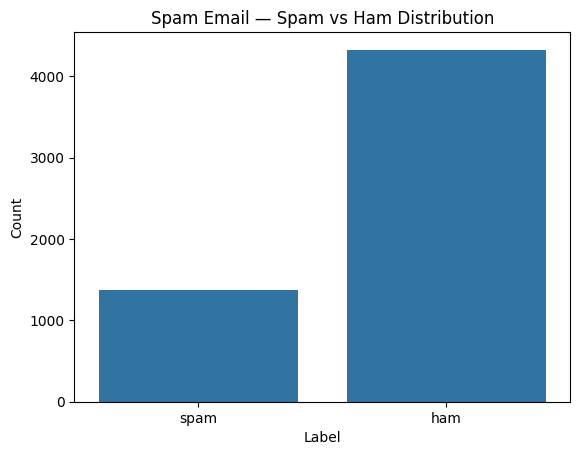

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='label', data=df)
plt.title('Spam Email — Spam vs Ham Distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.savefig('se_class_distribution.png')
plt.show()

        count         mean          std   min    25%     50%      75%      max
label                                                                         
ham    4327.0  1634.200139  1965.016383  13.0  577.5  1122.0  2037.50  43952.0
spam   1368.0  1317.257310  2271.372893  18.0  401.5   693.5  1250.25  28432.0


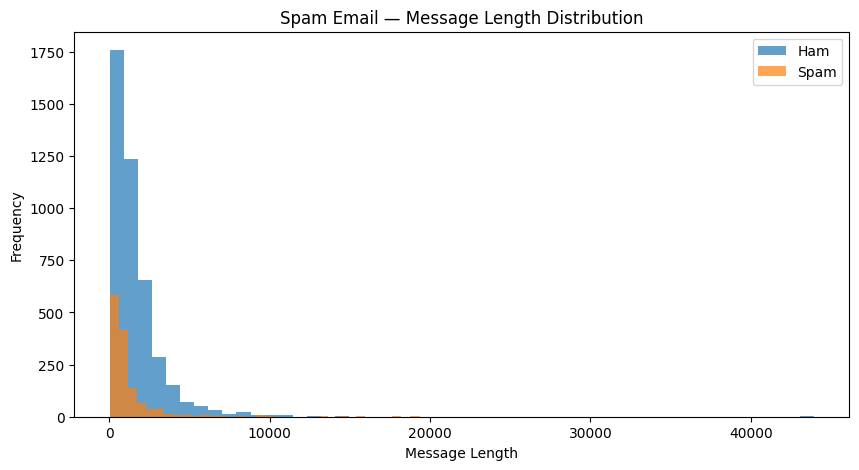

In [6]:
df['message_length'] = df['message'].apply(len)

print(df.groupby('label')['message_length'].describe())

plt.figure(figsize=(10,5))
df[df['label']=='ham']['message_length'].plot(
    bins=50, kind='hist', label='Ham', alpha=0.7)
df[df['label']=='spam']['message_length'].plot(
    bins=50, kind='hist', label='Spam', alpha=0.7)
plt.legend()
plt.title('Spam Email — Message Length Distribution')
plt.xlabel('Message Length')
plt.ylabel('Frequency')
plt.savefig('se_message_length_distribution.png')
plt.show()

In [7]:
import re

# Check for HTML tags
html_pattern = r'<[a-zA-Z][^>]*>'
spam_html = df[df['label']=='spam']['message'].apply(
    lambda x: bool(re.search(html_pattern, str(x)))).sum()
ham_html = df[df['label']=='ham']['message'].apply(
    lambda x: bool(re.search(html_pattern, str(x)))).sum()

print("=== Content Quality Check ===")
print(f"Spam with HTML tags: {spam_html} ({round(spam_html/df[df['label']=='spam'].shape[0]*100,1)}%)")
print(f"Ham with HTML tags:  {ham_html} ({round(ham_html/df[df['label']=='ham'].shape[0]*100,1)}%)")

# Check for email headers
header_pattern = r'(From:|To:|Received:|Return-Path:)'
spam_headers = df[df['label']=='spam']['message'].apply(
    lambda x: bool(re.search(header_pattern, str(x)))).sum()
ham_headers = df[df['label']=='ham']['message'].apply(
    lambda x: bool(re.search(header_pattern, str(x)))).sum()

print(f"\nSpam with headers: {spam_headers} ({round(spam_headers/df[df['label']=='spam'].shape[0]*100,1)}%)")
print(f"Ham with headers:  {ham_headers} ({round(ham_headers/df[df['label']=='ham'].shape[0]*100,1)}%)")
print("\n✅ Clean dataset — ready for preprocessing!")

=== Content Quality Check ===
Spam with HTML tags: 0 (0.0%)
Ham with HTML tags:  0 (0.0%)

Spam with headers: 0 (0.0%)
Ham with headers:  0 (0.0%)

✅ Clean dataset — ready for preprocessing!


In [9]:
import json

# Upload stats files when prompted
uploaded_stats = files.upload()  # Upload uci_stats.json, sa_stats.json

with open('uci_stats.json') as f:
    uci_stats = json.load(f)
with open('sa_stats.json') as f:
    sa_stats = json.load(f)

# SE stats - dynamic
se_stats = {
    'total': int(df.shape[0]),
    'ham_pct': round(df[df['label']=='ham'].shape[0]/df.shape[0]*100, 2),
    'spam_pct': round(df[df['label']=='spam'].shape[0]/df.shape[0]*100, 2),
    'avg_ham_length': round(df[df['label']=='ham']['message_length'].mean()),
    'avg_spam_length': round(df[df['label']=='spam']['message_length'].mean()),
    'html_tags': 'None',
    'headers': 'None',
    'content': 'Subject+Body',
    'domain': 'Email'
}

# Save SE stats
with open('se_stats.json', 'w') as f:
    json.dump(se_stats, f)

print("=== Dataset Comparison ===\n")
print(f"{'Property':<25} {'UCI SMS':<20} {'SpamAssassin':<20} {'SE Spam':<20}")
print("-" * 85)
print(f"{'Total messages':<25} {str(uci_stats['total']):<20} {str(sa_stats['total']):<20} {str(se_stats['total']):<20}")
print(f"{'Ham %':<25} {str(uci_stats['ham_pct'])+'%':<20} {str(sa_stats['ham_pct'])+'%':<20} {str(se_stats['ham_pct'])+'%':<20}")
print(f"{'Spam %':<25} {str(uci_stats['spam_pct'])+'%':<20} {str(sa_stats['spam_pct'])+'%':<20} {str(se_stats['spam_pct'])+'%':<20}")
print(f"{'Avg Ham length':<25} {str(uci_stats['avg_ham_length'])+' chars':<20} {str(sa_stats['avg_ham_length'])+' chars':<20} {str(se_stats['avg_ham_length'])+' chars':<20}")
print(f"{'Avg Spam length':<25} {str(uci_stats['avg_spam_length'])+' chars':<20} {str(sa_stats['avg_spam_length'])+' chars':<20} {str(se_stats['avg_spam_length'])+' chars':<20}")
print(f"{'HTML tags':<25} {uci_stats['html_tags']:<20} {sa_stats['html_tags']:<20} {se_stats['html_tags']:<20}")
print(f"{'Email headers':<25} {uci_stats['headers']:<20} {sa_stats['headers']:<20} {se_stats['headers']:<20}")
print(f"{'Content':<25} {uci_stats['content']:<20} {sa_stats['content']:<20} {se_stats['content']:<20}")
print(f"{'Domain':<25} {uci_stats['domain']:<20} {sa_stats['domain']:<20} {se_stats['domain']:<20}")

Saving sa_stats.json to sa_stats.json
Saving uci_stats.json to uci_stats.json
=== Dataset Comparison ===

Property                  UCI SMS              SpamAssassin         SE Spam             
-------------------------------------------------------------------------------------
Total messages            5169                 5329                 5695                
Ham %                     87.37%               68.27%               75.98%              
Spam %                    12.63%               31.73%               24.02%              
Avg Ham length            71 chars             3461 chars           1634 chars          
Avg Spam length           138 chars            5677 chars           1317 chars          
HTML tags                 None                 High                 None                
Email headers             None                 High                 None                
Content                   Body only            Full email           Subject+Body        
Domain 

In [10]:
import json

se_stats = {
    'total': int(df.shape[0]),
    'ham_count': int(df[df['label']=='ham'].shape[0]),
    'spam_count': int(df[df['label']=='spam'].shape[0]),
    'ham_pct': round(df[df['label']=='ham'].shape[0]/df.shape[0]*100, 2),
    'spam_pct': round(df[df['label']=='spam'].shape[0]/df.shape[0]*100, 2),
    'avg_ham_length': round(df[df['label']=='ham']['message_length'].mean()),
    'avg_spam_length': round(df[df['label']=='spam']['message_length'].mean()),
    'html_tags': 'None',
    'headers': 'None',
    'content': 'Subject+Body',
    'domain': 'Email'
}

with open('se_stats.json', 'w') as f:
    json.dump(se_stats, f)

print("SE stats saved!")
print(se_stats)

SE stats saved!
{'total': 5695, 'ham_count': 4327, 'spam_count': 1368, 'ham_pct': 75.98, 'spam_pct': 24.02, 'avg_ham_length': 1634, 'avg_spam_length': 1317, 'html_tags': 'None', 'headers': 'None', 'content': 'Subject+Body', 'domain': 'Email'}
